# Assignment 5: What Actually Gets Lost When You Compress?


## Step 1: Generate the Dataset

Same correlated 2D Gaussian as before. I need the features to be correlated so that PCA compression is meaningful — if they were independent, collapsing to 1D would lose a lot. With strong correlation, most of the variance fits along a single direction.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

mean = [0, 0]
cov  = [[3, 2.2],
        [2.2, 2]]

X = np.random.multivariate_normal(mean, cov, size=200)

# Center the data
X_mean     = X.mean(axis=0)
X_centered = X - X_mean

print(f"Dataset shape : {X.shape}")

Dataset shape : (200, 2)


## Step 2: Keep Only PC1 — Compress to 1D

I decompose the covariance matrix, grab the top eigenvector (PC1), and project every point onto it. That leaves one number per point — the PC1 score. PC2 gets dropped entirely.

In [2]:
# Eigendecomposition of covariance matrix
C = np.cov(X_centered.T)
eigenvalues, eigenvectors = np.linalg.eig(C)

# Sort descending
order        = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[order].real
eigenvectors = eigenvectors[:, order].real

pc1 = eigenvectors[:, 0]   # direction of max variance (shape: 2,)
pc2 = eigenvectors[:, 1]   # discarded direction

var_total = eigenvalues.sum()
print(f"PC1 explains : {eigenvalues[0]/var_total*100:.2f}% of variance  (kept)")
print(f"PC2 explains : {eigenvalues[1]/var_total*100:.2f}% of variance  (discarded)")

# Project onto PC1 only → 1D representation
scores_1d = X_centered @ pc1   # shape: (200,)
print(f"\nReduced data shape (1D): {scores_1d.shape}")

PC1 explains : 95.06% of variance  (kept)
PC2 explains : 4.94% of variance  (discarded)

Reduced data shape (1D): (200,)


## Step 3: Rebuild the 2D Points from 1D Scores

To reconstruct, I multiply each 1D score back by the PC1 direction and add the mean. Every reconstructed point ends up sitting on the PC1 line — they all "collapsed" to the nearest point on that line. Anything perpendicular to PC1 is permanently gone.

In [5]:
# Reconstruct: 1D scores × PC1 direction → back in 2D centered space, then un-center
X_reconstructed = np.outer(scores_1d, pc1) + X_mean   # shape: (200, 2)

print(f"Reconstructed data shape: {X_reconstructed.shape}")

# Reconstruction error per point (Euclidean distance between original and reconstructed)
errors = np.linalg.norm(X - X_reconstructed, axis=1)

print(f"\nReconstruction error per point:")
print(f"  Mean  : {errors.mean():.4f}")
print(f"  Max   : {errors.max():.4f}")
print(f"  Min   : {errors.min():.4f}")

# Total reconstruction error = variance captured by the dropped PC2
total_recon_error = np.sum(errors**2) / len(X)
print(f"\nMean squared reconstruction error : {total_recon_error:.4f}")
print(f"Eigenvalue of dropped PC2         : {eigenvalues[1]:.4f}  (should match)")

Reconstructed data shape: (200, 2)

Reconstruction error per point:
  Mean  : 0.3805
  Max   : 1.8911
  Min   : 0.0030

Mean squared reconstruction error : 0.2258
Eigenvalue of dropped PC2         : 0.2269  (should match)


## Step 4: Visualize the Loss

Two plots: the left shows original vs reconstructed points with gray lines connecting each pair (longer line = bigger error). The right shows the distribution of those errors. The PC1 line is the orange dashed line — every reconstructed point lands on it.

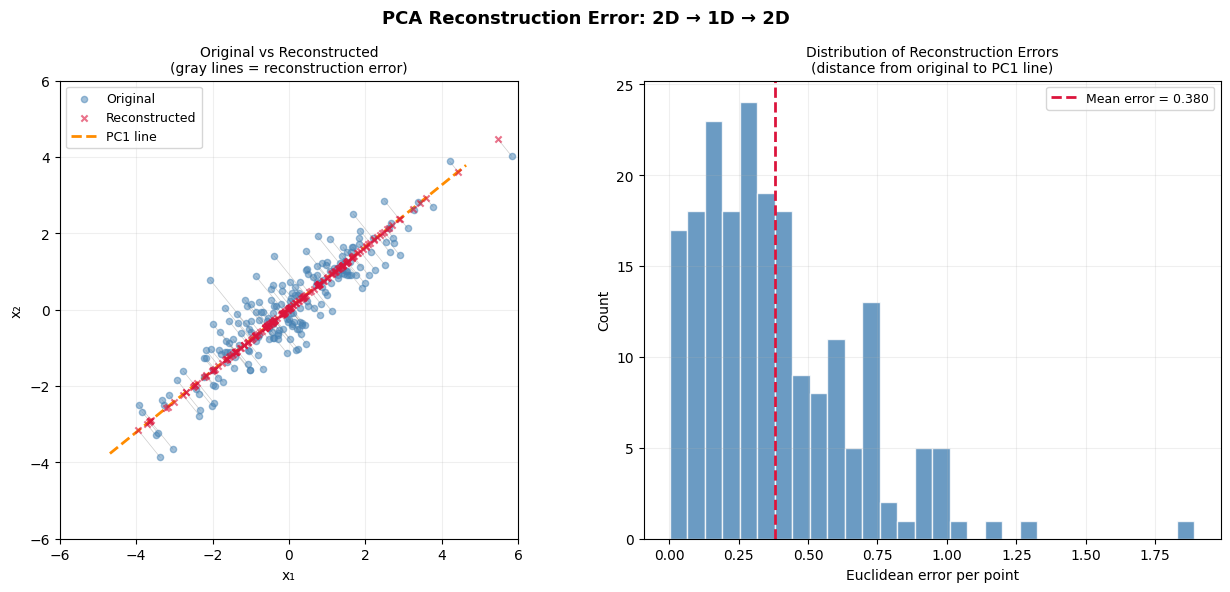

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# ── Left: Original + Reconstructed overlaid ──────────────────────────────────
ax = axes[0]
ax.scatter(X[:, 0], X[:, 1],
           alpha=0.5, s=20, color='steelblue', label='Original', zorder=3)
ax.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1],
           alpha=0.6, s=20, color='crimson', marker='x', label='Reconstructed', zorder=3)

# Draw error lines connecting original → reconstructed
for orig, recon in zip(X, X_reconstructed):
    ax.plot([orig[0], recon[0]], [orig[1], recon[1]],
            color='gray', lw=0.5, alpha=0.4, zorder=1)

# Draw the PC1 line (the line all reconstructed points lie on)
t = np.linspace(-6, 6, 200)
line = X_mean + np.outer(t, pc1)
ax.plot(line[:, 0], line[:, 1], color='darkorange', lw=2, ls='--', label='PC1 line', zorder=2)

ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
ax.set_aspect('equal')
ax.set_title('Original vs Reconstructed\n(gray lines = reconstruction error)', fontsize=10)
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# ── Right: Reconstruction error distribution ──────────────────────────────────
ax = axes[1]
ax.hist(errors, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(errors.mean(), color='crimson', lw=2, ls='--', label=f'Mean error = {errors.mean():.3f}')
ax.set_title('Distribution of Reconstruction Errors\n(distance from original to PC1 line)', fontsize=10)
ax.set_xlabel('Euclidean error per point')
ax.set_ylabel('Count')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

plt.suptitle('PCA Reconstruction Error: 2D → 1D → 2D', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/pca_assignment_5_reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()

## So What Actually Gets Lost?

When I reduce 2D → 1D by keeping only PC1:

- **What survives:** Each point's position along PC1 — the direction of maximum variance. This is the most informative part of the data.
- **What disappears:** Each point's distance off the PC1 line — its PC2 component. Every reconstructed point gets snapped to the line, so that perpendicular distance is permanently gone.
- **How much is lost:** The mean squared error equals the dropped eigenvalue (Lambda_2). PCA always drops the smallest eigenvalue first, so this is the minimum possible reconstruction error.

| Quantity | Formula |
|---|---|
| Variance retained (PC1) | Lambda_1 / (Lambda_1 + Lambda_2) × 100% |
| Variance lost (PC2) | Lambda_2 / (Lambda_1 + Lambda_2) × 100% |
| Mean squared error | ≈ Lambda_2 |

That last point is important: PCA is "optimal" in the sense that by always dropping the lowest-variance direction, it minimizes the reconstruction error compared to dropping any other direction. You cannot do better with a linear method.